In [ ]:
!pip install ftfy regex tqdm
!pip install git+https://github.com/openai/CLIP.git

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.5 MB/s eta 0:00:00
  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-ijz17k7b
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-ijz17k7b
  Resolved https://github.com/openai/CLIP.git to commit ded190a052fdf4585bd685cee5bc96e0310d2c93
  Preparing metadata (setup.py) ... done
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369490 sha256=240a1084bec997dbca189b52db4b26bd50c8f2ca9ead3ba576998a0cd81bfc2e
  Stored in directory: /tmp/pip-ephem-wheel-cache-h181x19d/wheels/35/3e/df/3d24cbfb3b6a06f17a2bfd7d1138900d4365d9028aa8f6e92f
Successfully built clip


In [ ]:
import requests
import clip
import torch
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device)
print(f"CLIP loaded on {device}")

100%|████████████████████████████████████████| 338M/338M [00:01<00:00, 182MiB/s]


CLIP loaded on cuda


In [ ]:
SEARCH_URL = "https://data.rijksmuseum.nl/search/collection"

def fetch_painting_ids(max_items=50):
    ids = []
    params = {
        "type": "painting",
        "material": "oil paint",
        "description": "stilleven",   # Dutch for still life
        "imageAvailable": "true"
    }
    url = SEARCH_URL

    while len(ids) < max_items:
        r = requests.get(url, params=params if url == SEARCH_URL else None)
        data = r.json()
        items = data.get("orderedItems", [])
        if not items:
            break
        ids.extend([item["id"] for item in items])
        print(f"Fetched {len(ids)} IDs...")
        next_page = data.get("next", {}).get("id")
        if not next_page or len(ids) >= max_items:
            break
        url = next_page
        params = None

    return ids[:max_items]

def get_image_url(obj_id):
    """Walk: object -> VisualItem -> DigitalObject -> access_point URL."""
    try:
        # step 1: fetch main object, get VisualItem ID
        r1 = requests.get(obj_id, headers={"Accept": "application/json"}, timeout=10)
        data = r1.json()
        vi_id = data.get("shows", [{}])[0].get("id")
        if not vi_id:
            return None

        # step 2: fetch VisualItem, get DigitalObject ID
        r2 = requests.get(vi_id, headers={"Accept": "application/json"}, timeout=10)
        vi = r2.json()
        do_id = vi.get("digitally_shown_by", [{}])[0].get("id")
        if not do_id:
            return None

        # step 3: fetch DigitalObject, get image URL
        r3 = requests.get(do_id, headers={"Accept": "application/json"}, timeout=10)
        dobj = r3.json()
        img_url = dobj.get("access_point", [{}])[0].get("id")
        if not img_url:
            return None

        # replace 'max' with '400,' for a smaller image (faster for CLIP)
        return img_url.replace("/max/", "/400,/")

    except:
        return None

def get_title(data):
    for item in data.get("identified_by", []):
        if item.get("type") == "Name":
            return item.get("content", "Untitled")
    return "Untitled"

def get_maker(data):
    prod = data.get("produced_by", {})
    for part in prod.get("part", []):
        for person in part.get("carried_out_by", []):
            label = person.get("_label")
            if label:
                return label
    return "Unknown"

# --- run ---
print("Fetching painting IDs...")
painting_ids = fetch_painting_ids(max_items=150)
print(f"\nTotal IDs: {len(painting_ids)}")

print("\nResolving images (3 requests per painting, ~5-10 min)...")
paintings = []
for i, obj_id in enumerate(painting_ids):
    r = requests.get(obj_id, headers={"Accept": "application/json"}, timeout=10)
    data = r.json()
    img_url = get_image_url(obj_id)
    if img_url:
        paintings.append({
            "title": get_title(data),
            "maker": get_maker(data),
            "img_url": img_url,
            "id": obj_id
        })
    if i % 10 == 0:
        print(f"  {i}/{len(painting_ids)} processed, {len(paintings)} with images")

print(f"\nDone. {len(paintings)} paintings with images.")
if paintings:
    p = paintings[0]
    print(f"Example: {p['title']} — {p['maker']}")
    print(f"Image URL: {p['img_url']}")

Fetching painting IDs...
Fetched 100 IDs...
Fetched 141 IDs...

Total IDs: 141

Resolving images (3 requests per painting, ~5-10 min)...
  0/141 processed, 1 with images
  10/141 processed, 11 with images
  20/141 processed, 21 with images
  30/141 processed, 30 with images
  40/141 processed, 39 with images
  50/141 processed, 49 with images
  60/141 processed, 59 with images
  70/141 processed, 69 with images
  80/141 processed, 79 with images
  90/141 processed, 89 with images
  100/141 processed, 99 with images
  110/141 processed, 109 with images
  120/141 processed, 119 with images
  130/141 processed, 129 with images
  140/141 processed, 139 with images

Done. 139 paintings with images.
Example: Stilleven met Nautilusbeker — Unknown
Image URL: https://iiif.micr.io/PGbwL/full/400,/0/default.jpg


In [ ]:

# --- your search prompts ---
PROMPTS = [
    "blue and white porcelain",
    "Chinese ceramic",
    "Delft blue",
    "blue and white ceramic",
    "porcelain on a table",
]

# encode all prompts once
text_tokens = clip.tokenize(PROMPTS).to(device);
with torch.no_grad():
    text_feats = model.encode_text(text_tokens);
    text_feats /= text_feats.norm(dim=-1, keepdim=True);

# average the prompt embeddings into one query vector
query = text_feats.mean(dim=0, keepdim=True);
query /= query.norm(dim=-1, keepdim=True);

def load_image(url):
    """Download and preprocess image for CLIP."""
    try:
        r = requests.get(url, timeout=10, headers={'User-Agent': 'Mozilla/5.0'}); # Added User-Agent here too
        r.raise_for_status(); # Check for HTTP errors
        img = Image.open(BytesIO(r.content)).convert("RGB");
        return preprocess(img).unsqueeze(0).to(device);
    except Exception as e: # Catch specific exceptions for better debugging
        print(f"Error loading image from {url}: {e}");
        return None;

# score each painting
results = [];
for i, p in enumerate(paintings):
    url = p.get("img_url");
    if not url:
        continue;
    img_tensor = load_image(url);
    if img_tensor is None:
        continue;
    with torch.no_grad():
        img_feat = model.encode_image(img_tensor);
        img_feat /= img_feat.norm(dim=-1, keepdim=True);
        score = (img_feat @ query.T).item();
    results.append({
        "title": p.get("title", "Untitled"),
        "maker": p.get("principalOrFirstMaker", "Unknown"),
        "score": score,
        "url": url,
        "page_url": p.get("id", "")  # Linked Art identifier doubles as the page URL
    });
    if i % 20 == 0:
        print(f"Processed {i}/{len(paintings)}...");

# sort by score descending
results.sort(key=lambda x: x["score"], reverse=True);
print(f"\nDone. Scored {len(results)} paintings.");
print("\nTop 10 matches:");
for r in results[:10]:
    print(f"  {r['score']:.3f} | {r['title']} — {r['maker']}");
    print(f"           {r['page_url']}");

Processed 0/139...
Processed 20/139...
Processed 40/139...
Processed 60/139...
Processed 80/139...
Processed 100/139...
Processed 120/139...

Done. Scored 139 paintings.

Top 10 matches:
  0.282 | Stilleven — Unknown
           https://id.rijksmuseum.nl/20029259
  0.273 | Stilleven met bloemen, vruchten en gevogelte — Unknown
           https://id.rijksmuseum.nl/200108670
  0.271 | Flowers in a Terra Cotta Vase — Unknown
           https://id.rijksmuseum.nl/20026739
  0.269 | Stilleven met kan van steengoed — Unknown
           https://id.rijksmuseum.nl/20028547
  0.263 | Still Life with Flowers — Unknown
           https://id.rijksmuseum.nl/200110737
  0.263 | Stilleven met vruchten, oesters en een porseleinen kom — Unknown
           https://id.rijksmuseum.nl/20027535
  0.262 | Still Life with Bagpipes — Unknown
           https://id.rijksmuseum.nl/20027411
  0.262 | Still Life with Fruit and a Goldfinch — Unknown
           https://id.rijksmuseum.nl/200108474
  0.262 | Stilleven met

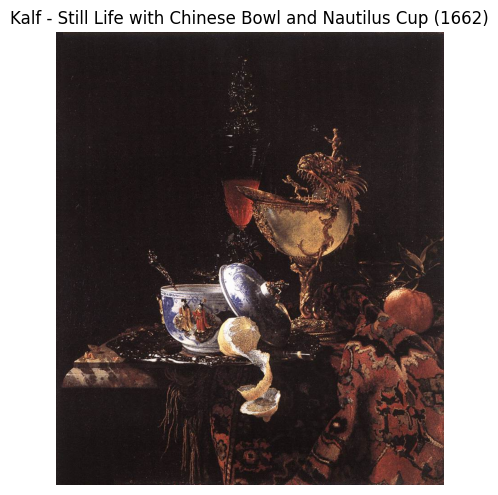

Kalf CLIP score: 0.291
Your current top score was: 0.273
Kalf ranks ABOVE your current top result


In [ ]:
# Score the Kalf WGA image directly using the same query vector from Step 4
# Make sure you have already run Steps 2 and 4 before this

IMG_URL = "https://www.wga.hu/art/k/kalf/nautilus.jpg"
r = requests.get(IMG_URL, headers={"User-Agent": "Mozilla/5.0"}, timeout=10)
img = Image.open(BytesIO(r.content)).convert("RGB")

# show it
plt.figure(figsize=(5, 7))
plt.imshow(img)
plt.title("Kalf - Still Life with Chinese Bowl and Nautilus Cup (1662)")
plt.axis("off")
plt.show()

# score it
img_tensor = preprocess(img).unsqueeze(0).to(device)
with torch.no_grad():
    img_feat = model.encode_image(img_tensor)
    img_feat /= img_feat.norm(dim=-1, keepdim=True)
    score = (img_feat @ query.T).item()

print(f"Kalf CLIP score: {score:.3f}")
print(f"Your current top score was: 0.273")
print(f"Kalf ranks {'ABOVE' if score > 0.273 else 'BELOW'} your current top result")

In [ ]:
# Known Rijksmuseum object numbers with confirmed Chinese/blue-white ceramics
# We'll resolve these directly and add them to the scored results

KNOWN_IDS = [
    "https://id.rijksmuseum.nl/200114831",  # Kalf - Still Life with Chinese bowl SK-A-2613
    "https://id.rijksmuseum.nl/200112438",  # van Beyeren - Banquet still life
    "https://id.rijksmuseum.nl/20027535",   # already in results - porcelain bowl (sanity check)
]

print("Resolving known ceramic paintings...")
for obj_id in KNOWN_IDS:
    r = requests.get(obj_id, headers={"Accept": "application/json"}, timeout=10)
    data = r.json()
    img_url = get_image_url(obj_id)
    if not img_url:
        print(f"  No image: {obj_id}")
        continue

    img_tensor = load_image(img_url)
    if img_tensor is None:
        print(f"  Image load failed: {obj_id}")
        continue

    with torch.no_grad():
        img_feat = model.encode_image(img_tensor)
        img_feat /= img_feat.norm(dim=-1, keepdim=True)
        score = (img_feat @ query.T).item()

    title = get_title(data)
    print(f"  Score: {score:.3f} | {title}")
    print(f"  URL: {obj_id}")

Resolving known ceramic paintings...
  Score: 0.241 | Table cover
  URL: https://id.rijksmuseum.nl/200114831
  No image: https://id.rijksmuseum.nl/200112438
  Score: 0.263 | Stilleven met vruchten, oesters en een porseleinen kom
  URL: https://id.rijksmuseum.nl/20027535
